# Notebook 04: Multi-Isotope Fitting

This notebook demonstrates the core scientific use case of NEREIDS: fitting a transmission spectrum containing **multiple isotopes simultaneously** to recover each isotope's areal density.

## Setup

We use two isotopes with well-separated resonances:
- **U-238**: resonance at 6.674 eV
- **Fictitious A=10 element** (SAMMY ex001): resonance at 10.0 eV

The separated resonances make the problem well-conditioned — each isotope's density is constrained by a different energy region.

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

In [2]:
# Define two isotopes
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

elem10 = nereids.create_resonance_data(
    z=1, a=10, awr=10.0, scattering_radius=2.908,
    resonances=[(10.0, 0.5, 0.5e-3, 1.0e-3)]
)

print(f"Isotope 1: {u238}")
print(f"Isotope 2: {elem10}")

Isotope 1: ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=1)
Isotope 2: ResonanceData(Z=1, A=10, AWR=10.000, n_resonances=1)


In [3]:
# Energy grid covering both resonances
# Fine spacing near each resonance, coarser in the wings
E_u238_core = np.linspace(6.674 - 0.3, 6.674 + 0.3, 400)
E_elem10_core = np.linspace(10.0 - 0.3, 10.0 + 0.3, 400)
E_bridge = np.linspace(6.974, 9.7, 100)  # between resonances
E_low = np.linspace(1.0, 6.374, 80)
E_high = np.linspace(10.3, 20.0, 80)

energies = np.sort(np.unique(np.concatenate([
    E_low, E_u238_core, E_bridge, E_elem10_core, E_high
])))

print(f"Energy grid: {len(energies)} points, [{energies[0]:.2f}, {energies[-1]:.2f}] eV")

Energy grid: 1057 points, [1.00, 20.00] eV


## 1. Individual Isotope Contributions

First, let's visualize how each isotope contributes to the transmission independently.

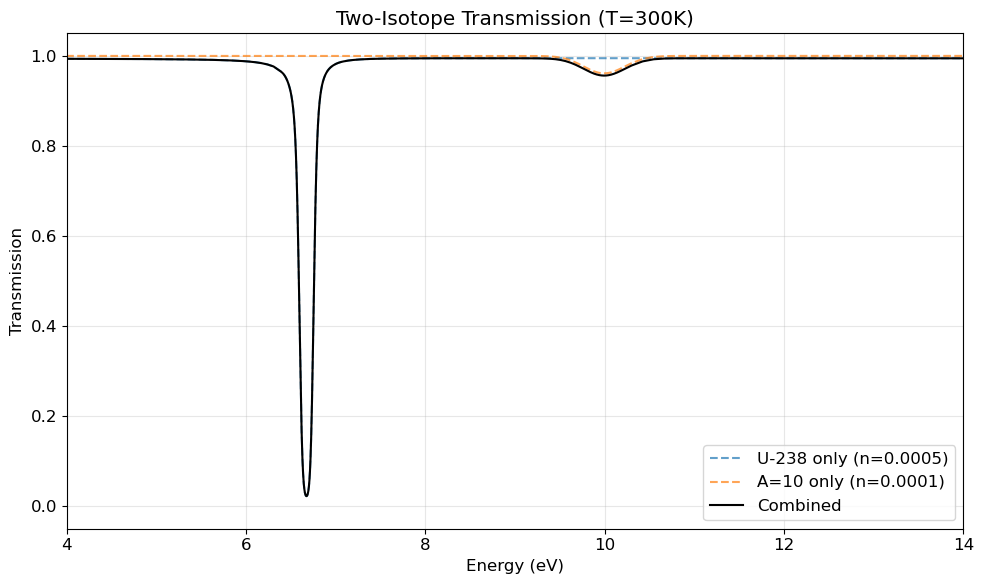

Combined vs product of individuals: max diff = 1.11e-16
Beer-Lambert additivity verified!


In [4]:
# True parameters
true_density_u238 = 5e-4   # atoms/barn
true_density_elem10 = 1e-4  # atoms/barn
temperature = 300.0  # K

# Individual contributions
T_u238_only = np.asarray(nereids.forward_model(
    energies, [(u238, true_density_u238)], temperature_k=temperature
))
T_elem10_only = np.asarray(nereids.forward_model(
    energies, [(elem10, true_density_elem10)], temperature_k=temperature
))

# Combined (both isotopes)
T_combined = np.asarray(nereids.forward_model(
    energies,
    [(u238, true_density_u238), (elem10, true_density_elem10)],
    temperature_k=temperature
))

fig, ax = plt.subplots()
ax.plot(energies, T_u238_only, '--', alpha=0.7, label=f'U-238 only (n={true_density_u238})')
ax.plot(energies, T_elem10_only, '--', alpha=0.7, label=f'A=10 only (n={true_density_elem10})')
ax.plot(energies, T_combined, 'k-', linewidth=1.5, label='Combined')

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Two-Isotope Transmission (T=300K)')
ax.legend()
ax.set_xlim(4, 14)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verify: combined T = product of individual T's (Beer-Lambert is additive in exponent)
T_product = T_u238_only * T_elem10_only
max_diff = np.max(np.abs(T_combined - T_product))
print(f"Combined vs product of individuals: max diff = {max_diff:.2e}")
assert max_diff < 1e-10, f"Beer-Lambert additivity violated: {max_diff}"
print("Beer-Lambert additivity verified!")

## 2. Simultaneous Two-Isotope Fit

In [5]:
# Generate noisy measurement
noise_level = 0.01
T_measured = T_combined + np.random.normal(0, noise_level, len(energies))
sigma = np.full_like(T_measured, noise_level)

# Fit both isotopes simultaneously
result = nereids.fit_spectrum(
    T_measured, sigma, energies,
    [u238, elem10],
    temperature_k=temperature,
    initial_densities=[1e-3, 1e-3],  # same initial guess for both
    max_iter=200
)

print(result)
print()
print(f"{'Isotope':<10} {'True':>12} {'Fitted':>12} {'Uncertainty':>12} {'Rel Error':>10}")
print("-" * 60)

true_densities = [true_density_u238, true_density_elem10]
names = ['U-238', 'A=10']

for i, name in enumerate(names):
    rel_err = abs(result.densities[i] - true_densities[i]) / true_densities[i] * 100
    print(f"{name:<10} {true_densities[i]:>12.6f} {result.densities[i]:>12.6f} {result.uncertainties[i]:>12.6f} {rel_err:>9.2f}%")

print(f"\nReduced χ²: {result.reduced_chi_squared:.4f}")
print(f"Converged:  {result.converged}")
print(f"Iterations: {result.iterations}")

assert result.converged, "Fit did not converge!"
for i in range(2):
    rel_err = abs(result.densities[i] - true_densities[i]) / true_densities[i] * 100
    assert rel_err < 10, f"{names[i]} relative error {rel_err:.1f}% exceeds 10% threshold"

FitResult(converged=true, chi2_red=0.9544, densities=[0.0004986660698901516, 9.772057956457483e-5])

Isotope            True       Fitted  Uncertainty  Rel Error
------------------------------------------------------------
U-238          0.000500     0.000499     0.000001      0.27%
A=10           0.000100     0.000098     0.000002      2.28%

Reduced χ²: 0.9544
Converged:  True
Iterations: 5


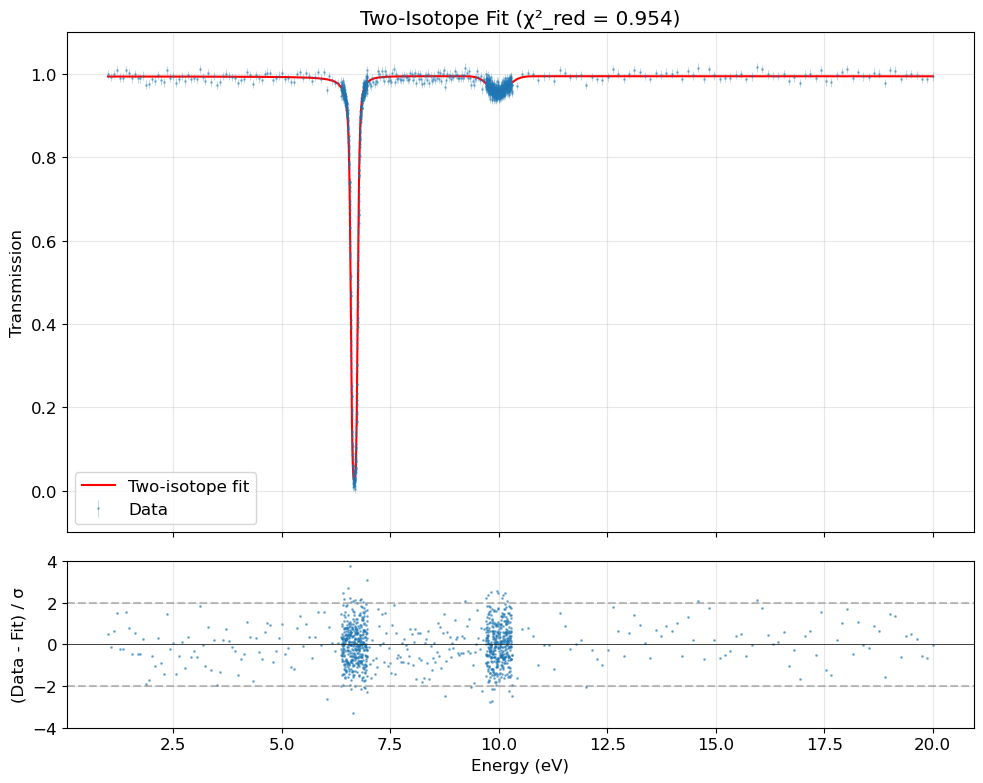

In [6]:
# Visualize the fit
T_fitted = np.asarray(nereids.forward_model(
    energies,
    [(u238, result.densities[0]), (elem10, result.densities[1])],
    temperature_k=temperature
))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax = axes[0]
ax.errorbar(energies, T_measured, yerr=sigma, fmt='.', markersize=2,
            alpha=0.4, label='Data', elinewidth=0.5)
ax.plot(energies, T_fitted, 'r-', linewidth=1.5, label='Two-isotope fit')
ax.set_ylabel('Transmission')
ax.set_title(f'Two-Isotope Fit (χ²_red = {result.reduced_chi_squared:.3f})')
ax.legend()
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

ax = axes[1]
residuals = (T_measured - T_fitted) / sigma
ax.scatter(energies, residuals, s=1, alpha=0.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(2, color='gray', linestyle='--', alpha=0.5)
ax.axhline(-2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('(Data - Fit) / σ')
ax.set_ylim(-4, 4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Thickness Sensitivity Scan

Vary the true U-238 density over a wide range, fit each time, and verify the fitted density tracks the true value.

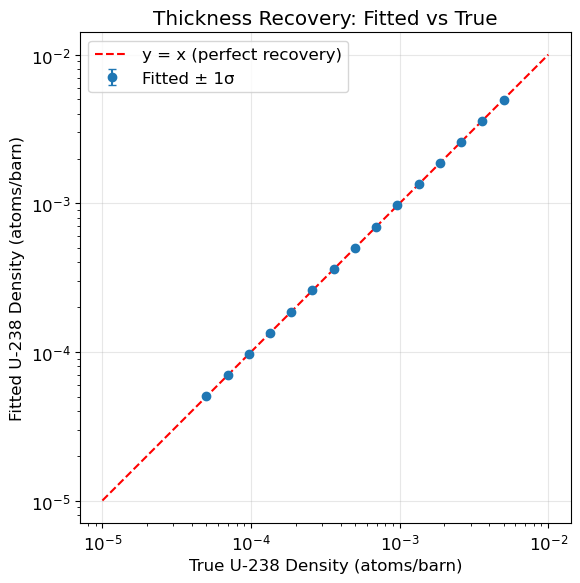

In [7]:
# Fix elem10 density, vary U-238
true_u238_scan = np.geomspace(5e-5, 5e-3, 15)
fitted_u238_scan = []
fitted_u238_unc = []

for n_true in true_u238_scan:
    # Generate data
    T_gen = np.asarray(nereids.forward_model(
        energies,
        [(u238, float(n_true)), (elem10, true_density_elem10)],
        temperature_k=temperature
    ))
    T_noisy = T_gen + np.random.normal(0, noise_level, len(energies))

    # Fit
    r = nereids.fit_spectrum(
        T_noisy, sigma, energies, [u238, elem10],
        temperature_k=temperature,
        initial_densities=[1e-3, 1e-3],
        max_iter=200
    )
    fitted_u238_scan.append(r.densities[0])
    fitted_u238_unc.append(r.uncertainties[0])

fitted_u238_scan = np.array(fitted_u238_scan)
fitted_u238_unc = np.array(fitted_u238_unc)

fig, ax = plt.subplots()
ax.errorbar(true_u238_scan, fitted_u238_scan, yerr=fitted_u238_unc,
            fmt='o', capsize=3, label='Fitted ± 1σ')
ax.plot([1e-5, 1e-2], [1e-5, 1e-2], 'r--', label='y = x (perfect recovery)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('True U-238 Density (atoms/barn)')
ax.set_ylabel('Fitted U-238 Density (atoms/barn)')
ax.set_title('Thickness Recovery: Fitted vs True')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 4. Cross-Talk: What Happens with Overlapping Resonances?

When two isotopes have resonances at similar energies, the fit becomes harder because the parameters are correlated. Let's demonstrate this by creating a second isotope with a resonance close to U-238's.

In [8]:
# Create a fictitious isotope with resonance CLOSE to U-238 (6.674 + 0.5 eV)
nearby = nereids.create_resonance_data(
    z=50, a=120, awr=120.0, scattering_radius=7.0,
    resonances=[(7.2, 0.5, 2.0e-3, 20.0e-3)]  # resonance at 7.2 eV
)

true_n_u238 = 5e-4
true_n_nearby = 3e-4

# Well-separated case (U-238 + A=10)
T_separated = np.asarray(nereids.forward_model(
    energies,
    [(u238, true_n_u238), (elem10, true_density_elem10)],
    temperature_k=temperature
))
T_separated_noisy = T_separated + np.random.normal(0, noise_level, len(energies))

r_sep = nereids.fit_spectrum(
    T_separated_noisy, sigma, energies,
    [u238, elem10],
    temperature_k=temperature,
    initial_densities=[1e-3, 1e-3],
    max_iter=200
)

# Overlapping case (U-238 + nearby)
T_overlapping = np.asarray(nereids.forward_model(
    energies,
    [(u238, true_n_u238), (nearby, true_n_nearby)],
    temperature_k=temperature
))
T_overlapping_noisy = T_overlapping + np.random.normal(0, noise_level, len(energies))

r_over = nereids.fit_spectrum(
    T_overlapping_noisy, sigma, energies,
    [u238, nearby],
    temperature_k=temperature,
    initial_densities=[1e-3, 1e-3],
    max_iter=200
)

print("=== Well-Separated Resonances (U-238 at 6.674 eV + A=10 at 10.0 eV) ===")
print(f"  U-238: fitted = {r_sep.densities[0]:.6f}, true = {true_n_u238:.6f}, unc = {r_sep.uncertainties[0]:.6f}")
print(f"  A=10:  fitted = {r_sep.densities[1]:.6f}, true = {true_density_elem10:.6f}, unc = {r_sep.uncertainties[1]:.6f}")
print(f"  χ²_red = {r_sep.reduced_chi_squared:.4f}")
print()
print("=== Overlapping Resonances (U-238 at 6.674 eV + nearby at 7.2 eV) ===")
print(f"  U-238:  fitted = {r_over.densities[0]:.6f}, true = {true_n_u238:.6f}, unc = {r_over.uncertainties[0]:.6f}")
print(f"  Nearby: fitted = {r_over.densities[1]:.6f}, true = {true_n_nearby:.6f}, unc = {r_over.uncertainties[1]:.6f}")
print(f"  χ²_red = {r_over.reduced_chi_squared:.4f}")
print()
print("Note: overlapping resonances typically produce LARGER uncertainties")
print("due to parameter correlation (the fit cannot easily distinguish")
print("which isotope causes the dip).")

=== Well-Separated Resonances (U-238 at 6.674 eV + A=10 at 10.0 eV) ===
  U-238: fitted = 0.000498, true = 0.000500, unc = 0.000001
  A=10:  fitted = 0.000099, true = 0.000100, unc = 0.000002
  χ²_red = 0.9983

=== Overlapping Resonances (U-238 at 6.674 eV + nearby at 7.2 eV) ===
  U-238:  fitted = 0.000499, true = 0.000500, unc = 0.000001
  Nearby: fitted = 0.000296, true = 0.000300, unc = 0.000003
  χ²_red = 0.9760

Note: overlapping resonances typically produce LARGER uncertainties
due to parameter correlation (the fit cannot easily distinguish
which isotope causes the dip).


## 5. Complete Analysis Workflow Summary

Here is the full NEREIDS 1D analysis workflow in a single cell:

In [9]:
# ========================================
# NEREIDS 1D Analysis Workflow
# ========================================

# Step 1: Define isotopes with resonance parameters
isotope_A = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)
isotope_B = nereids.create_resonance_data(
    z=1, a=10, awr=10.0, scattering_radius=2.908,
    resonances=[(10.0, 0.5, 0.5e-3, 1.0e-3)]
)

# Step 2: Define energy grid
energies = np.sort(np.concatenate([
    np.linspace(1, 6, 60),
    np.linspace(6, 7.5, 400),     # fine near U-238 resonance
    np.linspace(7.5, 9.5, 60),
    np.linspace(9.5, 10.5, 400),  # fine near A=10 resonance
    np.linspace(10.5, 15, 60),
]))

# Step 3: Compute forward model (for validation or synthetic data)
T_model = nereids.forward_model(
    energies,
    [(isotope_A, 5e-4), (isotope_B, 1e-4)],
    temperature_k=300.0
)

# Step 4: In real use, load measured T(E) and uncertainties here
# For this demo, we use synthetic data
measured = np.asarray(T_model) + np.random.normal(0, 0.01, len(energies))
sigma = np.full(len(energies), 0.01)

# Step 5: Fit to recover isotopic compositions
result = nereids.fit_spectrum(
    measured, sigma, energies,
    [isotope_A, isotope_B],
    temperature_k=300.0
)

# Step 6: Extract results
print("=== NEREIDS Fit Results ===")
print(f"U-238 areal density: {result.densities[0]:.6f} ± {result.uncertainties[0]:.6f} atoms/barn")
print(f"A=10 areal density:  {result.densities[1]:.6f} ± {result.uncertainties[1]:.6f} atoms/barn")
print(f"Reduced χ²:          {result.reduced_chi_squared:.4f}")
print(f"Converged:           {result.converged}")

=== NEREIDS Fit Results ===
U-238 areal density: 0.000497 ± 0.000002 atoms/barn
A=10 areal density:  0.000097 ± 0.000003 atoms/barn
Reduced χ²:          1.0133
Converged:           True


## Summary

In this notebook we demonstrated:

1. **Multi-isotope forward model**: Beer-Lambert law is additive in the exponent — `T_combined = T_A × T_B`
2. **Simultaneous fitting**: `fit_spectrum()` recovers both densities accurately from a combined spectrum
3. **Thickness sensitivity**: fitted density tracks true density over two orders of magnitude
4. **Resonance overlap**: nearby resonances increase parameter uncertainty due to correlation
5. **Complete workflow**: define isotopes → forward model → fit → extract compositions

### Current Limitations (to be addressed in future work)

- **No ENDF retrieval from Python**: must manually specify resonance parameters
- **Single L=0 group**: `create_resonance_data()` only supports s-wave resonances
- **No resolution broadening in fit**: `fit_spectrum()` uses `instrument=None` internally
- **No spatial/2D mapping from Python**: per-pixel fitting requires the Rust pipeline or GUI
- **Single resonance per isotope in demos**: real isotopes have hundreds of resonances from ENDF

### What's Next

- Add ENDF retrieval to Python bindings for real isotope data
- Add resolution broadening support to `fit_spectrum()`
- 2D spatial mapping notebooks once the pipeline is exposed to Python
- Validation against real VENUS experimental data